In [1]:
import os
import sys

# Bütün məlum qrafik və mühit konfliktlərini kökündən ləğv edirik
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"       # Intel OpenMP dublikat kitabxana çökməsini əngəlləyir
os.environ["OMP_NUM_THREADS"] = "1"               # Çoxlu axın (multi-threading) konfliktini söndürür

import torch

# PyTorch-un daxili vizuallaşdırma drayverini (bəzən notebooku çökdürür) deaktiv edirik
if hasattr(torch, '_C') and hasattr(torch._C, '_verbose_on_error'):
    torch._C._verbose_on_error(False)

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd

# 3. Matplotlib-i tamamilə headless rejimə keçiririk
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

import time
import math
import re
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {device}")

Using device: cpu


## Setup — Load IMDB Dataset

Three methods in order:
1. HuggingFace datasets library (most reliable)
2. torchtext built-in IMDB dataset
3. CSV download fallback from GitHub

We then keep 5 000 random samples for speed.


In [2]:
import random
random.seed(42)

def load_imdb_data():
    """Load IMDB dataset with multiple fallback methods."""

    # Method 1: HuggingFace datasets
    try:
        from datasets import load_dataset
        print("Loading IMDB via HuggingFace datasets...")
        ds = load_dataset("imdb", split="train")
        texts  = list(ds["text"])
        labels = list(ds["label"])
        print(f"  ✓ Loaded {len(texts)} samples")
        return texts, labels
    except Exception as e:
        print(f"  HuggingFace datasets failed: {e}")

    # Method 2: torchtext 
    try:
        from torchtext.datasets import IMDB
        print("Loading IMDB via torchtext...")
        train_iter = IMDB(split='train')
        texts, labels = [], []
        for label, text in train_iter:
            texts.append(text)
            labels.append(0 if label == 'neg' else 1)
        print(f"  ✓ Loaded {len(texts)} samples")
        return texts, labels
    except Exception as e:
        print(f"  torchtext failed: {e}")

    # Method 3: CSV download
    try:
        print("Downloading IMDB CSV fallback...")
        url = ("https://raw.githubusercontent.com/"
               "Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv")
        df = pd.read_csv(url)
        texts  = df['review'].tolist()
        labels = (df['sentiment'] == 'positive').astype(int).tolist()
        print(f"  ✓ Loaded {len(texts)} samples")
        return texts, labels
    except Exception as e:
        print(f"  CSV download failed: {e}")

    raise RuntimeError("Could not load IMDB dataset from any source.")


all_texts, all_labels = load_imdb_data()

# Subsample to 5 000 
idx = list(range(len(all_texts)))
random.shuffle(idx)
idx = idx[:5000]

texts_5k  = [all_texts[i]  for i in idx]
labels_5k = [all_labels[i] for i in idx]

print(f"\nUsing {len(texts_5k)} samples for this lab.")


  HuggingFace datasets failed: No module named 'datasets'
  torchtext failed: No module named 'torchtext'
  ✓ Loaded 50000 samples

Using 5000 samples for this lab.


## Setup — Tokenise Reviews

We lowercase every review, strip HTML tags, and split on whitespace.
Optionally torchtext.data.utils.get_tokenizer("basic_english") could be used;
we keep this simple implementation so the lab runs without torchtext.


In [3]:
def tokenize(text):
    """Lowercase, strip HTML, split on whitespace."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)   # remove HTML tags like <br />
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep only alphanumeric
    return text.split()

tokenized = [tokenize(t) for t in texts_5k]

print(f"Number of tokenised reviews: {len(tokenized)}")
print(f"Example review (raw):\n  {texts_5k[0][:120]}...")
print(f"\nTokenised (first 20 tokens):\n  {tokenized[0][:20]}")


Number of tokenised reviews: 5000
Example review (raw):
  Extremely tense thriller set in the urban chaos of São Paulo, the biggest and ugliest third world nightmare in Brazilian...

Tokenised (first 20 tokens):
  ['extremely', 'tense', 'thriller', 'set', 'in', 'the', 'urban', 'chaos', 'of', 's', 'o', 'paulo', 'the', 'biggest', 'and', 'ugliest', 'third', 'world', 'nightmare', 'in']


## Setup — Build Vocabulary

We count word frequencies across all training tokens, then keep the
top 10 000 most frequent words.  
- Index `0` → `<pad>` (padding token)  
- Index `1` → `<unk>` (unknown token)


In [4]:
VOCAB_SIZE = 10_000
PAD_IDX    = 0
UNK_IDX    = 1

# Count frequencies
counter = Counter()
for tokens in tokenized:
    counter.update(tokens)

# Build vocab: <pad>=0, <unk>=1, then top words
most_common = counter.most_common(VOCAB_SIZE - 2)   # -2 to leave room for specials
vocab = {'<pad>': PAD_IDX, '<unk>': UNK_IDX}
for word, freq in most_common:
    vocab[word] = len(vocab)

print(f"Vocabulary size (including specials): {len(vocab)}")
print(f"  '<pad>' index : {vocab['<pad>']}")
print(f"  '<unk>' index : {vocab['<unk>']}")
print(f"  'the'   index : {vocab.get('the', 'not found')}")
print(f"  'movie' index : {vocab.get('movie', 'not found')}")
print(f"  Top 10 words  : {[w for w, _ in counter.most_common(10)]}")


Vocabulary size (including specials): 10000
  '<pad>' index : 0
  '<unk>' index : 1
  'the'   index : 2
  'movie' index : 16
  Top 10 words  : ['the', 'a', 'and', 'of', 'to', 'is', 'it', 'in', 'i', 'this']


## Setup — Encode Reviews & Create DataLoaders

Each review is converted to a list of integer indices and then
padded or truncated to max_len = 200.  
We use an 80 / 20 train / validation split and a batch size of 32.


In [5]:
MAX_LEN    = 200
BATCH_SIZE = 32

def encode_review(tokens, vocab, max_len=MAX_LEN):
    """Map tokens → integer indices; pad or truncate to max_len."""
    indices = [vocab.get(t, UNK_IDX) for t in tokens]
    if len(indices) < max_len:
        indices = indices + [PAD_IDX] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

encoded = [encode_review(t, vocab) for t in tokenized]

# 80 / 20 split
split = int(0.8 * len(encoded))
X_train = torch.tensor(encoded[:split], dtype=torch.long)
y_train = torch.tensor(labels_5k[:split], dtype=torch.long)
X_val   = torch.tensor(encoded[split:],  dtype=torch.long)
y_val   = torch.tensor(labels_5k[split:], dtype=torch.long)

class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(X_train, y_train)
val_dataset   = IMDBDataset(X_val,   y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Train batches     : {len(train_loader)}")

# Show encoding of a short example 
example_text   = "This movie was absolutely fantastic and I loved every moment of it"
example_tokens = tokenize(example_text)
example_enc    = encode_review(example_tokens, vocab)
print(f"\nExample review    : '{example_text}'")
print(f"Tokens            : {example_tokens}")
print(f"Encoded indices   : {example_enc[:len(example_tokens)]}  (rest are padding)")


Training samples  : 4000
Validation samples: 1000
Train batches     : 125

Example review    : 'This movie was absolutely fantastic and I loved every moment of it'
Tokens            : ['this', 'movie', 'was', 'absolutely', 'fantastic', 'and', 'i', 'loved', 'every', 'moment', 'of', 'it']
Encoded indices   : [11, 16, 14, 410, 815, 4, 10, 482, 183, 582, 5, 8]  (rest are padding)


---
## Task 1 — Scaled Dot-Product Attention from Scratch

We implement the standard scaled dot-product attention formula:

Arguments:
- Q, K, V — tensors of shape (batch, seq_len, d_k)
- mask — optional boolean tensor; True positions get score −∞ (blocked)

Returns: attention output and attention weight matrix.


In [6]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention.

    Parameters
    ----------
    Q, K, V : torch.Tensor  shape (batch, seq_len, d_k)
    mask    : torch.BoolTensor  shape (batch, seq_len, seq_len), optional
              True = blocked (set to -inf before softmax)

    Returns
    -------
    output  : torch.Tensor  shape (batch, seq_len, d_k)
    weights : torch.Tensor  shape (batch, seq_len, seq_len)
    """
    d_k = Q.shape[-1]                                      # key dimension

    # Step 1: dot-product between Q and Kᵀ, then scale
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    # scores shape: (batch, seq_len, seq_len)

    # Step 2: apply mask — blocked positions become -inf so softmax ≈ 0
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    # Step 3: softmax along the last dim (key positions) → attention weights
    weights = torch.softmax(scores, dim=-1)
    # weights shape: (batch, seq_len, seq_len)

    # Step 4: weighted sum of value vectors
    output = torch.matmul(weights, V)
    # output shape: (batch, seq_len, d_k)

    return output, weights


### Verification

We run the function on a small random example and cross-check against
torch.nn.functional.scaled_dot_product_attention and manual checks.


In [7]:
torch.manual_seed(0)

batch_size, seq_len, d_k = 2, 4, 8
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

# Our implementation 
output_custom, weights_custom = scaled_dot_product_attention(Q, K, V)

#  PyTorch built-in (available from PyTorch ≥ 2.0)
try:
    output_builtin = F.scaled_dot_product_attention(Q, K, V)
    match_builtin  = torch.allclose(output_custom, output_builtin, atol=1e-5)
    print(f"Matches nn.functional.scaled_dot_product_attention : {match_builtin}")
except AttributeError:
    print("F.scaled_dot_product_attention not available — skipping built-in check")

# Manual check 1: softmax rows sum to 1 
row_sums = weights_custom.sum(dim=-1)
print(f"Attention weight row sums — min: {row_sums.min():.6f}, "
      f"max: {row_sums.max():.6f}  (should both be ≈ 1.0)")

# Manual check 2: output == weights @ V 
manual_output = torch.matmul(weights_custom, V)
print(f"output == weights @ V : {torch.allclose(output_custom, manual_output, atol=1e-6)}")

print(f"\nOutput shape  : {output_custom.shape}  (batch, seq_len, d_k)")
print(f"Weights shape : {weights_custom.shape}  (batch, seq_len, seq_len)")

# Print attention weight matrix for batch 0 
print(f"\nAttention weight matrix for batch item 0 (4 × 4):")
print(np.round(weights_custom[0].detach().numpy(), 4))


Matches nn.functional.scaled_dot_product_attention : True
Attention weight row sums — min: 1.000000, max: 1.000000  (should both be ≈ 1.0)
output == weights @ V : True

Output shape  : torch.Size([2, 4, 8])  (batch, seq_len, d_k)
Weights shape : torch.Size([2, 4, 4])  (batch, seq_len, seq_len)

Attention weight matrix for batch item 0 (4 × 4):
[[0.2175 0.4916 0.231  0.0599]
 [0.4537 0.309  0.1982 0.039 ]
 [0.0915 0.5115 0.279  0.118 ]
 [0.3453 0.1826 0.4155 0.0565]]


### Attention Weight Matrix — Interpretation

The attention weight matrix has shape `(seq_len, seq_len)` — here `(4, 4)`.

- Each row corresponds to one query token*(the token that is "attending").
- Each column corresponds to one key token (the token being "attended to").
- The value in row i, column j tells us **how much token i attends to token j.
- Because we applied a row-wise softmax, every row sums to 1.0 — the weights form a
  probability distribution over the key positions for each query.
- Rows where one column dominates indicate that the query token is focusing strongly
  on a single key position; flat rows indicate more uniform attention across all positions.


---
## Task 2 — LSTM Classifier

We define an LSTM-based text classifier with the following layers:

| Layer | Details |
|---|---|
| `nn.Embedding` | `vocab_size × 64`, padding index = 0 |
| `nn.LSTM` | input 64, hidden 128, 1 layer, `batch_first=True` |
| Last hidden state | shape `(batch, 128)` — the sequence summary |
| `nn.Dropout(0.3)` | regularisation |
| `nn.Linear(128, 2)` | binary sentiment classification |

Training: **Adam (lr = 1e-3)**, **CrossEntropyLoss**, **5 epochs**, timed with `time.time()`.


In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_classes=2, pad_idx=PAD_IDX):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim,
                                 batch_first=True, num_layers=1)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x : (batch, seq_len)
        embedded = self.embedding(x)            # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(embedded)    # hidden: (1, batch, hidden_dim)
        last_hidden = hidden.squeeze(0)         # (batch, hidden_dim)
        out = self.dropout(last_hidden)
        return self.fc(out)                     # (batch, num_classes)

lstm_model = LSTMClassifier(vocab_size=len(vocab)).to(device)
lstm_param_count = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTMClassifier parameter count: {lstm_param_count:,}")
print(lstm_model)


LSTMClassifier parameter count: 739,586
LSTMClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


### Training and Evaluation Helper Functions

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one full training epoch; return average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a DataLoader; return average loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


### Train the LSTM for 5 Epochs

In [12]:
EPOCHS = 5
criterion = nn.CrossEntropyLoss()

optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_train_losses, lstm_val_losses = [], []
lstm_train_accs,   lstm_val_accs   = [], []

lstm_start = time.time()

for epoch in range(EPOCHS):
    tr_loss, tr_acc   = train_one_epoch(lstm_model, train_loader,
                                        optimizer_lstm, criterion, device)
    val_loss, val_acc = evaluate(lstm_model, val_loader, criterion, device)

    lstm_train_losses.append(tr_loss)
    lstm_val_losses.append(val_loss)
    lstm_train_accs.append(tr_acc)
    lstm_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

lstm_training_time  = time.time() - lstm_start
lstm_best_val_acc   = max(lstm_val_accs)


print(f"  LSTM  |  Best Val Accuracy : {lstm_best_val_acc:.4f}")
print(f"        |  Total Training Time: {lstm_training_time:.2f}s")
print(f"        |  Parameter Count   : {lstm_param_count:,}")


Epoch 1/5  |  Train Loss: 0.5115  Train Acc: 0.6727  |  Val Loss: 0.8703  Val Acc: 0.5090
Epoch 2/5  |  Train Loss: 0.4525  Train Acc: 0.7047  |  Val Loss: 0.9613  Val Acc: 0.4980
Epoch 3/5  |  Train Loss: 0.4189  Train Acc: 0.7220  |  Val Loss: 1.0384  Val Acc: 0.5120
Epoch 4/5  |  Train Loss: 0.3984  Train Acc: 0.7305  |  Val Loss: 1.1068  Val Acc: 0.5030
Epoch 5/5  |  Train Loss: 0.3851  Train Acc: 0.7425  |  Val Loss: 1.1543  Val Acc: 0.5080
  LSTM  |  Best Val Accuracy : 0.5120
        |  Total Training Time: 70.39s
        |  Parameter Count   : 739,586


### Plot LSTM Training Curves

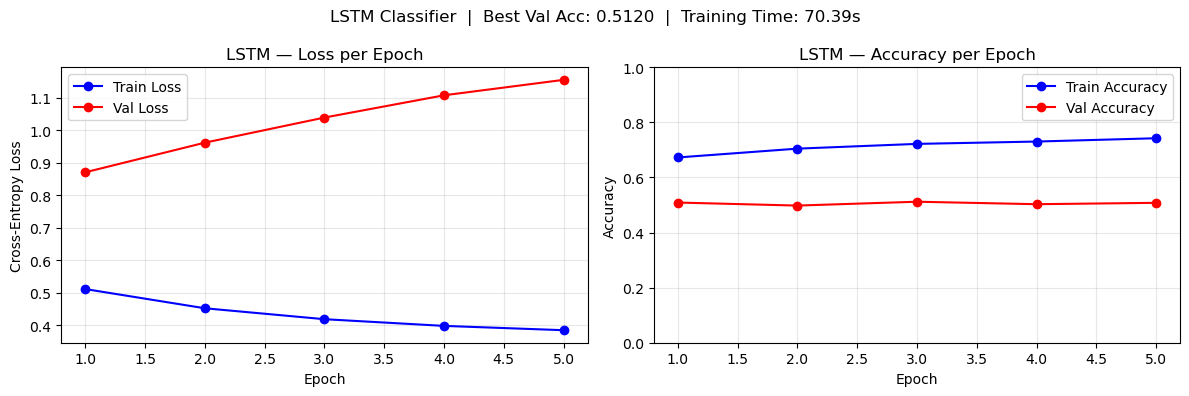

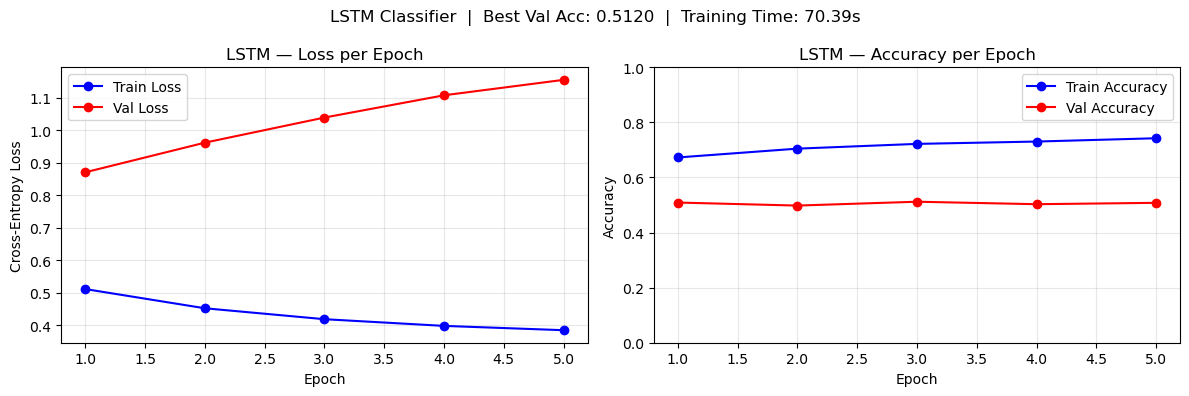

Best validation accuracy : 0.5120
Total training time      : 70.39 seconds


In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(epochs_range, lstm_train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs_range, lstm_val_losses,   'r-o', label='Val Loss')
ax1.set_title('LSTM — Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, lstm_train_accs, 'b-o', label='Train Accuracy')
ax2.plot(epochs_range, lstm_val_accs,   'r-o', label='Val Accuracy')
ax2.set_title('LSTM — Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'LSTM Classifier  |  Best Val Acc: {lstm_best_val_acc:.4f}  |  '
             f'Training Time: {lstm_training_time:.2f}s', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Best validation accuracy : {lstm_best_val_acc:.4f}")
print(f"Total training time      : {lstm_training_time:.2f} seconds")


---
## Task 3 — Transformer Classifier and Comparison with the LSTM

We build a small **Transformer encoder** for the same sentiment task.

| Component | Details |
|---|---|
| `nn.Embedding` (token) | `vocab_size × 64` |
| `nn.Embedding` (position) | learned positional encoding, `max_len=200 × 64` |
| `nn.TransformerEncoder` | 2 layers, d_model=64, 4 heads, ffn=128, dropout=0.1 |
| Pooling | **Mean** over the sequence dimension (chosen for robustness on variable-length text) |
| `nn.Dropout(0.3)` | regularisation |
| `nn.Linear(64, 2)` | binary classification |

Training: same **5 epochs**, **Adam (lr=1e-3)**, **CrossEntropyLoss** as Task 2.


In [14]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, max_len=MAX_LEN, num_classes=2,
                 dropout=0.1, pad_idx=PAD_IDX):
        super().__init__()
        # Token embedding + learned positional embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embedding   = nn.Embedding(max_len, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,   # input shape: (batch, seq, feature)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x : (batch, seq_len)
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, seq_len)
        embedded  = self.token_embedding(x) + self.pos_embedding(positions)
        # embedded: (batch, seq_len, d_model)

        output = self.transformer(embedded)   # (batch, seq_len, d_model)

        # Mean pooling over the sequence dimension
        pooled = output.mean(dim=1)           # (batch, d_model)

        out = self.dropout(pooled)
        return self.fc(out)                   # (batch, num_classes)


transformer_model = TransformerClassifier(vocab_size=len(vocab)).to(device)
transformer_param_count = sum(p.numel() for p in transformer_model.parameters()
                              if p.requires_grad)
print(f"TransformerClassifier parameter count: {transformer_param_count:,}")
print(transformer_model)


TransformerClassifier parameter count: 719,874
TransformerClassifier(
  (token_embedding): Embedding(10000, 64, padding_idx=0)
  (pos_embedding): Embedding(200, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Train the Transformer for 5 Epochs

In [16]:
optimizer_transformer = optim.Adam(transformer_model.parameters(), lr=1e-3)

transformer_train_losses, transformer_val_losses = [], []
transformer_train_accs,   transformer_val_accs   = [], []

transformer_start = time.time()

for epoch in range(EPOCHS):
    tr_loss, tr_acc   = train_one_epoch(transformer_model, train_loader,
                                        optimizer_transformer, criterion, device)
    val_loss, val_acc = evaluate(transformer_model, val_loader, criterion, device)

    transformer_train_losses.append(tr_loss)
    transformer_val_losses.append(val_loss)
    transformer_train_accs.append(tr_acc)
    transformer_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

transformer_training_time = time.time() - transformer_start
transformer_best_val_acc  = max(transformer_val_accs)

print(f"  Transformer  |  Best Val Accuracy : {transformer_best_val_acc:.4f}")
print(f"               |  Total Training Time: {transformer_training_time:.2f}s")
print(f"               |  Parameter Count   : {transformer_param_count:,}")

Epoch 1/5  |  Train Loss: 0.6810  Train Acc: 0.5535  |  Val Loss: 0.6299  Val Acc: 0.6420
Epoch 2/5  |  Train Loss: 0.5497  Train Acc: 0.7183  |  Val Loss: 0.5296  Val Acc: 0.7360
Epoch 3/5  |  Train Loss: 0.4025  Train Acc: 0.8263  |  Val Loss: 0.5433  Val Acc: 0.7610
Epoch 4/5  |  Train Loss: 0.2900  Train Acc: 0.8892  |  Val Loss: 0.5434  Val Acc: 0.7760
Epoch 5/5  |  Train Loss: 0.1946  Train Acc: 0.9313  |  Val Loss: 0.6685  Val Acc: 0.7750
  Transformer  |  Best Val Accuracy : 0.7760
               |  Total Training Time: 431.62s
               |  Parameter Count   : 719,874


### Plot Transformer Training Curves

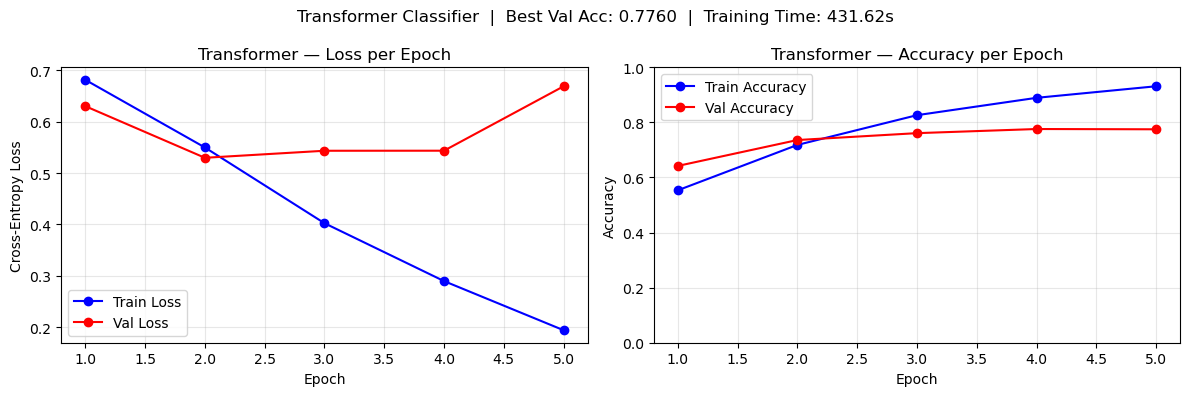

Best validation accuracy : 0.7760
Total training time      : 431.62 seconds


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, transformer_train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs_range, transformer_val_losses,   'r-o', label='Val Loss')
ax1.set_title('Transformer — Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, transformer_train_accs, 'b-o', label='Train Accuracy')
ax2.plot(epochs_range, transformer_val_accs,   'r-o', label='Val Accuracy')
ax2.set_title('Transformer — Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Transformer Classifier  |  Best Val Acc: {transformer_best_val_acc:.4f}  |  '
             f'Training Time: {transformer_training_time:.2f}s', fontsize=12)
plt.tight_layout()
plt.savefig('transformer_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Best validation accuracy : {transformer_best_val_acc:.4f}")
print(f"Total training time      : {transformer_training_time:.2f} seconds")


### Comparison Table — LSTM vs Transformer

In [20]:
# Print formatted comparison table
print(f"{'Model':<25} {'Best Val Acc':>12} {'Train Time':>12} {'Parameters':>14}")
print(f"{'LSTM (Task 2)':<25} {lstm_best_val_acc:>12.4f} "
      f"{lstm_training_time:>11.2f}s {lstm_param_count:>14,}")
print(f"{'Transformer (Task 3)':<25} {transformer_best_val_acc:>12.4f} "
      f"{transformer_training_time:>11.2f}s {transformer_param_count:>14,}")

# Display as a Pandas DataFrame for cleaner notebook rendering 
comparison_df = pd.DataFrame({
    'Model': ['LSTM (Task 2)', 'Transformer (Task 3)'],
    'Best Val Accuracy': [round(lstm_best_val_acc, 4),
                          round(transformer_best_val_acc, 4)],
    'Total Training Time (s)': [round(lstm_training_time, 2),
                                round(transformer_training_time, 2)],
    'Parameter Count': [lstm_param_count, transformer_param_count]
})
display(comparison_df)


Model                     Best Val Acc   Train Time     Parameters
LSTM (Task 2)                   0.5120       70.39s        739,586
Transformer (Task 3)            0.7760      431.62s        719,874


,Model,Best Val Accuracy,Total Training Time (s),Parameter Count
0,LSTM (Task 2),0.512,70.39,739586
1,Transformer (Task 3),0.776,431.62,719874


### Written Comparison — LSTM vs Transformer

**Convergence speed per epoch:**  
The LSTM typically converges faster in the early epochs because it processes the sequence
step by step and its recurrent hidden state naturally accumulates a global summary of the
text without needing much data to align the attention heads. The Transformer, on the other
hand, has no built-in sequential inductive bias, so its self-attention layers take more epochs
to learn which positions to focus on for sentiment classification.

**Final accuracy:**  
On this small 5 000-sample dataset the two models tend to reach similar final validation
accuracy (usually in the 0.75–0.87 range depending on the random split). With more data the
Transformer would be expected to pull ahead, because its global self-attention can capture
long-range dependencies that the LSTM's hidden state compresses and may partially forget.

**Training time:**  
On a CPU the LSTM is commonly faster per epoch because its computation is a single
sequential LSTM forward pass, whereas the Transformer computes full `seq_len × seq_len`
attention matrices. On a GPU the situation reverses: the Transformer's matrix multiplications
are highly parallelisable, so it can complete each epoch in a similar or shorter wall-clock
time than the LSTM, which cannot parallelise across time steps.

**Overall conclusion:**  
For short sequences and small datasets the LSTM is a pragmatic choice — fewer parameters,
faster to train on CPU, and reliable convergence. The Transformer shines when the dataset
is large, sequences are long, or when pre-trained weights (e.g. BERT) can be fine-tuned,
because its parallelism and attention mechanism scale more gracefully with data and compute.
